<a href="https://colab.research.google.com/github/elvissoares/EQE595-SimMol/blob/main/C%C3%B3pia_de_6_OpenMM_e_Agua.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula Prática 06 - Dinâmica Molecular da Água usando OpenMM

Autor: [Prof. Elvis do A. Soares](https://github.com/elvissoares)

Contato: [elvis@peq.coppe.ufrj.br](mailto:elvis@peq.coppe.ufrj.br) - [Programa de Engenharia Química, PEQ/COPPE, UFRJ, Brasil](https://www.peq.coppe.ufrj.br/)

---

Para usar o OpenMM no Google Colab **SEMPRE** devemos fazer o seguinte passo:
1. Instalar o `openmm[cuda12]` e o `mdtraj` via `pip`


In [1]:
%%capture
!pip install openmm[cuda12] mdtraj

2. Testando se a instalação deu certo e quais `Platform` estão disponíveis

In [2]:
!python -m openmm.testInstallation


OpenMM Version: 8.5.2
Git Revision: 36a30cbca54e727b216b606f3c011b67201eb8b4

There are 4 Platforms available:

1 Reference - Successfully computed forces
2 CPU - Successfully computed forces
3 CUDA - Successfully computed forces
1 warning generated.
1 warning generated.
4 OpenCL - Successfully computed forces

Median difference in forces between platforms:

Reference vs. CPU: 6.29859e-06
Reference vs. CUDA: 6.74146e-06
CPU vs. CUDA: 7.66607e-07
Reference vs. OpenCL: 6.74321e-06
CPU vs. OpenCL: 7.81307e-07
CUDA vs. OpenCL: 1.79472e-07

All differences are within tolerance.


Chamando as bibliotecas necessárias

In [3]:
from sys import stdout
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
from openmm.app import *
from openmm import *
from openmm.unit import *

## Topologia da Molécula de Água

Definindo a topologia da molécula de água H-O-H --> [Molécula da Água](https://en.wikipedia.org/wiki/Water_model#/media/File:Water-2D-labelled.png)

In [5]:
mol_topology = app.Topology()
chain = mol_topology.addChain()
residue = mol_topology.addResidue("water", chain)
element_O = app.Element.getByAtomicNumber(8)
element_H = app.Element.getByAtomicNumber(1)
atom0 = mol_topology.addAtom("O", element_O, residue)
atom1 = mol_topology.addAtom("H", element_H, residue)
atom2 = mol_topology.addAtom("H", element_H, residue)
mol_topology.addBond(atom0, atom1)
mol_topology.addBond(atom0, atom2)

In [6]:
print(mol_topology)
print("Número de átomos:", mol_topology.getNumAtoms())
for iatom, atom in enumerate(mol_topology.atoms()):
    print(f"Nome e massa do átomo {iatom}: {atom.name}, {atom.element.mass}")

<Topology; 1 chains, 1 residues, 3 atoms, 2 bonds>
Número de átomos: 3
Nome e massa do átomo 0: O, 15.99943 Da
Nome e massa do átomo 1: H, 1.007947 Da
Nome e massa do átomo 2: H, 1.007947 Da


## Campos de Força Gerais

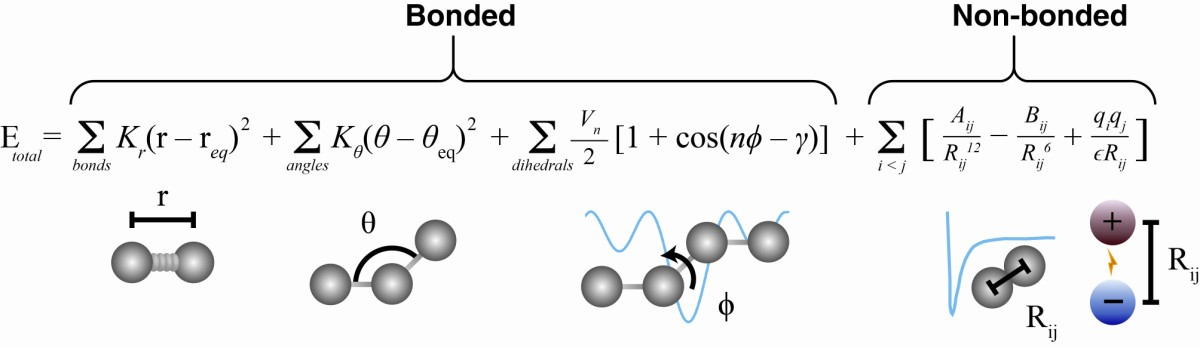

## Termos Ligantes

### 1. Termo de Comprimento da ligação

$$U_\text{bond} = \frac{k_l}{2}(l - l_0)^2$$

Para água, no TIP3, temos
- $l_0=0.09572$ nm
- $k_l=462750.4$ kJ/(nm $^2$ mol)

### 2. Termo de ângulo de ligação

$$ U_{\text{angle}} = \frac{k_\theta}{2}(\theta-\theta_0)^2$$

Para água no TIP3 temos
- $\theta_0=1.82421813418$ rad
- $k_\theta = 836.8$ kJ/mol

### 3. Termo de torção

$$ U_\text{torcao} = \frac{k_\text{torcao}}{2}\cos(n\phi-\phi_0)$$

Água não possui ângulo de torção.

## Termos Não-ligantes

### 1. Dispersão de van der Waals

$$ U_\text{vdW} = \frac{A_{ij}}{r_{ij}^{12}} - \frac{B_{ij}}{r_{ij}^6}$$

### 2. Interação eletrostática

$$ U_\text{ele} = \frac{q_i q_j}{4\pi \epsilon r_{ij}}$$

Escolhendo o campo de força para a água (TIP3P) [Water Model](https://en.wikipedia.org/wiki/Water_model)

In [7]:
forcefield = ForceField('amber14/tip3p.xml')

Definindo o sistema para simulação

In [8]:
system = forcefield.createSystem(mol_topology, nonbondedCutoff=1 * nanometer)

platform = Platform.getPlatformByName('CUDA') # ou 'CUDA' se tiver GPU
properties = {
    "DeviceIndex": "0",      # T4 GPU
    "Precision": "single",   # or "mixed" for better energy conservation
}

# c. Definition an integrator, mandatory.
integrator = VerletIntegrator(1 * femtoseconds)

# d. A simulation object in OpenMM combines topology, system and integrator.
simulation = Simulation(mol_topology, system, integrator, platform)

# Definindo a geometria inicial da molécula
bond = 0.9572  # Å
angle = 1.82421813418 # rad (104.52° in radians)
simulation.context.setPositions(
    np.array([
    [0.0,         0.0,         0.0        ],  # O
    [ bond,       0.0,         0.0        ],  # H1
    [ bond*np.cos(angle), bond*np.sin(angle), 0.0 ],  # H2
]) * angstrom
)

In [9]:
force = system.getForce(0)
print("Parâmetros da força de ligação O-H:")
for i in range(force.getNumBonds()):
    l = force.getBondParameters(i)
    print(f"Parâmetro {i}: {l}")

print()
force_angle = system.getForce(3)
print("Parâmetros da interação de ângulo H-O-H:")
for i in range(force_angle.getNumAngles()):
    theta = force_angle.getAngleParameters(i)
    print(f"Parâmetro {i}: {theta}")

Parâmetros da força de ligação O-H:
Parâmetro 0: [0, 1, 0.09572 nm, 462750.4 kJ/(nm**2 mol)]
Parâmetro 1: [0, 2, 0.09572 nm, 462750.4 kJ/(nm**2 mol)]

Parâmetros da interação de ângulo H-O-H:
Parâmetro 0: [1, 0, 2, 1.82421813418 rad, 836.8 kJ/(mol rad**2)]


## Cálculo de Energia de comprimento da ligação O-H na molécula de H2O

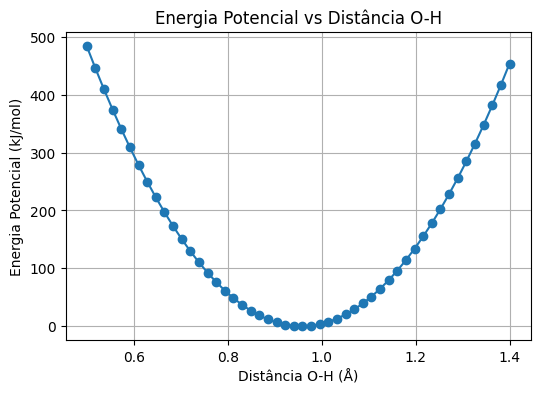

In [10]:
# loop sobre distancias entre o átomo de oxigênio e o hidrogênio 1 e calcula a energia potencial
distances = np.linspace(0.5, 1.4, 50) * angstrom
energies = []
for distance in distances:
    simulation.context.setPositions(
        np.array([
            [0.0, 0.0, 0.0],  # O
            [distance.value_in_unit(angstrom), 0.0, 0.0],  # H1
            [bond * np.cos(angle), bond * np.sin(angle), 0.0]  # H2
        ]) * angstrom
    )
    state = simulation.context.getState(getEnergy=True)
    energies.append(state.getPotentialEnergy().value_in_unit(kilojoule_per_mole))

# Convertendo as energias para um array NumPy
energies = np.array(energies)

# Criando um gráfico de energia potencial versus distância
plt.figure(figsize=(6, 4))
plt.plot(distances.value_in_unit(angstrom), energies, marker='o', linestyle='-', color='C0')
plt.title('Energia Potencial vs Distância O-H')
plt.xlabel('Distância O-H (Å)')
plt.ylabel('Energia Potencial (kJ/mol)')
plt.grid()


## Cálculo de Energia de ângulo da ligação H-O-H na molécula de H2O

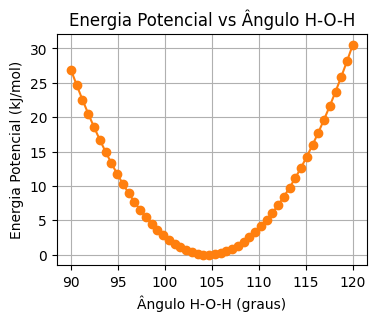

In [12]:
# loop sobre valores do ângulo entre H-O-H e calcula a energia potencial
angles = np.linspace(90, 120, 50) * np.pi / 180  # Ângulos de 90 a 150 graus
energies_angle = []
for angle in angles:
    simulation.context.setPositions(
        np.array([
            [0.0, 0.0, 0.0],  # O
            [bond, 0.0, 0.0],  # H1
            [bond * np.cos(angle), bond * np.sin(angle), 0.0]  # H2
        ]) * angstrom
    )
    state = simulation.context.getState(getEnergy=True)
    energies_angle.append(state.getPotentialEnergy().value_in_unit(kilojoule_per_mole))

# Convertendo as energias para um array NumPy
energies_angle = np.array(energies_angle)

# Criando um gráfico de energia potencial versus ângulo
plt.figure(figsize=(4, 3))
plt.plot(np.degrees(angles), energies_angle, marker='o', linestyle='-', color='C1')
plt.title('Energia Potencial vs Ângulo H-O-H')
plt.xlabel('Ângulo H-O-H (graus)')
plt.ylabel('Energia Potencial (kJ/mol)')
plt.grid()


## Cálcula o equilíbrio da molécula

Posições antes do equilíbrio

In [13]:
# Definindo a geometria inicial da molécula
bond = 0.95  # Å
angle = 105.0 * np.pi/180
simulation.context.setPositions(
    np.array([
    [0.0,         0.0,         0.0        ],  # O
    [ bond,       0.0,         0.0        ],  # H1
    [ bond*np.cos(angle), bond*np.sin(angle), 0.0 ],  # H2
]) * angstrom
)

state = simulation.context.getState(getPositions=True, getForces=True, getEnergy=True)
print("Energia potencial: ", state.getPotentialEnergy())
print()
print("Posições Atômicas")
print(state.getPositions(asNumpy=True))
print()

Energia potencial:  0.26925569772720337 kJ/mol

Posições Atômicas
[[ 0.          0.          0.        ]
 [ 0.095       0.          0.        ]
 [-0.02458781  0.09176295  0.        ]] nm



Minimiza a energia da molécula de acordo com o campo de força TIP3

In [14]:
simulation.minimizeEnergy()

Posições e infos após o equilíbrio da molécula

In [15]:
state = simulation.context.getState(getPositions=True, getForces=True, getEnergy=True)
print("Energia potencial: ", state.getPotentialEnergy())
print()
print("Posições Atômicas")
print(state.getPositions(asNumpy=True))
print()

Energia potencial:  9.59005319600692e-09 kJ/mol

Posições Atômicas
[[-3.06726521e-04 -3.99715937e-04  0.00000000e+00]
 [ 9.54123288e-02  1.15570219e-06  0.00000000e+00]
 [-2.46934071e-02  9.21614990e-02  0.00000000e+00]] nm



Calcula distancia O-H e ângulo H-O-H de equilíbrio

In [16]:
# comprimento O-H, em nanometros.
eq_pos = state.getPositions(asNumpy=True)
l0 = np.linalg.norm(eq_pos[1] - eq_pos[0])
print('Comprimento da Ligação O-H: ',l0,  'nm')

# ângulo H-O-H
d01 = eq_pos[1] - eq_pos[0]
d02 = eq_pos[2] - eq_pos[0]
d01 /= np.linalg.norm(d01)
d02 /= np.linalg.norm(d02)
cosine = np.dot(d01, d02)
theta0 = np.arccos(cosine)
print('Ângulo da Ligação H-O-H: ', theta0, 'rad, ',np.degrees(theta0), 'graus')

Comprimento da Ligação O-H:  0.0957198947819728 nm
Ângulo da Ligação H-O-H:  1.8242196623559312 rad,  104.52008755777491 graus


---

# Dinâmica Molecular com Água

Definição da caixa de simulação

In [17]:
18*1e3/(30*1e-8)**3/6.022e23

1.1070519207350826

In [18]:
L = 30 * angstrom

box_matrix = L * np.identity(3)
topology = Topology()
topology.setPeriodicBoxVectors(box_matrix)

N_mol = 1000

resname = next(mol_topology.residues()).name

for i in range(N_mol):
    chain   = topology.addChain()
    residue = topology.addResidue(resname, chain)
    atom_map = {}

    # 1) add atoms
    for atom in mol_topology.atoms():
        new = topology.addAtom(atom.name, atom.element, residue)
        atom_map[atom] = new

    # 2) add the same bonds
    for bond in mol_topology.bonds():
        a1 = atom_map[bond.atom1]
        a2 = atom_map[bond.atom2]
        topology.addBond(a1, a2)

Colocando cada molécula em um lugar distinto da caixa

In [19]:
# Coloca cada molécula em uma posição aleatória dentro da caixa cúbica

all_pos = []
i = 0
for x in np.arange(0,1.0,0.1)*L/angstrom:
  for y in np.arange(0,1.0,0.1)*L/angstrom:
    for z in np.arange(0,1.0,0.1)*L/angstrom:
      if i < N_mol:
        # CMpos = np.random.uniform(0, L / nanometer, 3)
        CMpos = np.array([x,y,z])
        coords = CMpos + eq_pos/nanometer
        all_pos.append(coords)
        i += 1

Definindo integrador para simulação NVT

In [27]:
temperatura = 300 * kelvin

system = forcefield.createSystem(topology, nonbondedMethod=PME,
        nonbondedCutoff=1*nanometer, constraints=HBonds)

integrator = LangevinMiddleIntegrator(temperatura, 1/picosecond, 4*femtoseconds)

simulation = Simulation(topology, system, integrator,platform)
simulation.context.setPositions(np.vstack(all_pos) * angstrom)
simulation.minimizeEnergy()
simulation.context.setVelocitiesToTemperature(temperatura)

In [28]:
positions = simulation.context.getState(getPositions=True).getPositions()

PDBFile.writeFile(topology, positions, open('initial_water.pdb', 'w'))

Definindo os relatórios

In [29]:
# Remove reporters existentes, no caso dessa célula ser executada mais de uma vez.
simulation.reporters = []

# Escreve cada frame em arquivo DCD de trajetórias a cada 1000 passos
simulation.reporters.append(PDBReporter("output_water.pdb", 1000))

# Escreve num arquivo csv a cada 20 passos
simulation.reporters.append(
    StateDataReporter(
        "md_log_water.csv",
        20,
        step=True,
        time=True,
        potentialEnergy=True,
        totalEnergy=True,
        temperature=True,
        volume=True
    )
)

# Escreve na tela a cada 1000 passos
simulation.reporters.append(
    StateDataReporter(stdout, 1000, step=True, totalEnergy=True,temperature=True,
        volume=True)
)

## Equilibração NVT

In [30]:
print("Equilibrando com NVT")

simulation.step(5000)

Equilibrando com NVT
#"Step","Total Energy (kJ/mole)","Temperature (K)","Box Volume (nm^3)"
1000,-31836.859015853668,302.52640276874104,27.0
2000,-31465.734595687652,297.75094637941163,27.0
3000,-31426.2582468107,298.54154572357845,27.0
4000,-31281.31973973062,300.0863853695012,27.0
5000,-31605.706183822418,299.8685668402662,27.0


## Produção NPT

In [31]:
pressao = 1*bar

system.addForce(MonteCarloBarostat(pressao, temperatura))
simulation.context.reinitialize(preserveState=True)


print("Rodando NPT")
simulation.step(70000)

# A próxima linha é necessária para Windows para fechar os arquivos antes de serem abertos
del simulation

Rodando NPT
6000,-31030.815976288577,292.85043234190096,29.71166933094151
7000,-29947.926149878156,306.24197460690704,30.591895171932418
8000,-30833.06487833953,300.90189552573526,30.500194925417183
9000,-30654.475213692174,298.5637371612825,30.18337706842876
10000,-30837.69928315046,301.4088741955838,30.174590679240367
11000,-30591.225945143495,298.78195856079356,30.580836484618423
12000,-30282.327773129946,313.87576203207726,30.646386124157743
13000,-30393.5817988707,298.54980456423687,30.191854382749597
14000,-30891.45063050522,301.20589472151556,29.713031608743997
15000,-30712.34628410131,302.51727104248454,30.80028033593478
16000,-30697.44231819344,303.3643057978172,29.892054375846364
17000,-31339.792116744182,292.0540920963009,30.15920320588583
18000,-30653.431929315993,302.6710667703553,29.836052559770625
19000,-30964.959585057426,300.5883281608995,30.101873244516998
20000,-30756.910330240964,294.42135783819606,30.160291276125726
21000,-30935.70115974039,288.08380552612107,30.25

## Análise dos dados

In [25]:
import mdtraj

traj = mdtraj.load("output_water.dcd", top="initial_water.pdb")

In [32]:
df = pd.read_csv("md_log_water.csv")

In [33]:
df.head()

,"#""Step""",Time (ps),Potential Energy (kJ/mole),Total Energy (kJ/mole),Temperature (K),Box Volume (nm^3)
0,20,0.08,-35715.165382,-25389.038429,354.994314,27.0
1,40,0.16,-37484.857032,-25889.913673,398.614019,27.0
2,60,0.24,-37971.736305,-26927.390602,379.685427,27.0
3,80,0.32,-37713.865577,-26773.671241,376.104884,27.0
4,100,0.40,-37974.497016,-27295.534126,367.124201,27.0


In [35]:
df['Box Volume (nm^3)']

,Box Volume (nm^3)
0,27.000000
1,27.000000
2,27.000000
3,27.000000
4,27.000000
...,...
3745,30.567376
3746,30.831642
3747,30.831642
3748,30.823963


Text(0, 0.5, 'Volume (nm$^3$)')

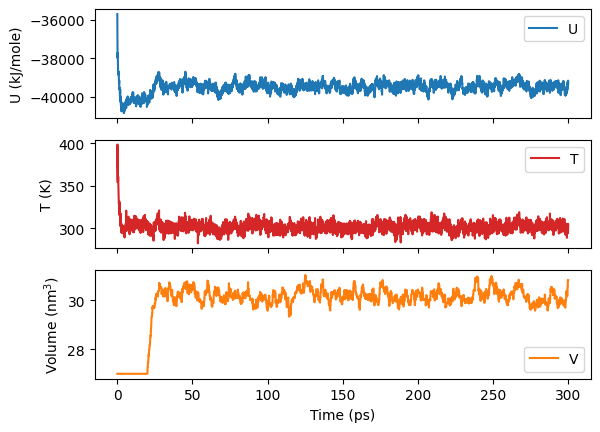

In [36]:
fig, axs = plt.subplots(3, 1, sharex=True)

axs[0].plot(df['Time (ps)'],df['Potential Energy (kJ/mole)'],color='C0',label='U')
axs[0].legend(loc='best')
axs[0].set_ylabel('U (kJ/mole)')

axs[1].plot(df['Time (ps)'],df['Temperature (K)'],color='C3',label='T')
axs[1].legend(loc='best')
axs[1].set_ylabel('T (K)')

axs[2].plot(df['Time (ps)'],df['Box Volume (nm^3)'],color='C1',label='V')
axs[2].legend(loc='best')
axs[2].set_xlabel('Time (ps)')
axs[2].set_ylabel('Volume (nm$^3$)')

> ⚠️ Qual o melhor tempo para cortar a fase de equilibração?

In [37]:
timecut = 50

In [38]:
subsetT = df['Temperature (K)'][df['Time (ps)'] > timecut]
subsetU = df['Potential Energy (kJ/mole)'][df['Time (ps)'] > timecut]
subsetV = df['Box Volume (nm^3)'][df['Time (ps)'] > timecut]

In [39]:
from IPython.display import display, Math

# Cálculo da média e desvio padrão da energia potencial U
Umean = subsetU.mean()
sigmaU = subsetU.std()

display(Math(rf"U = {Umean:.2f} \pm {sigmaU:.2f}\ kJ/mole"))

<IPython.core.display.Math object>

In [40]:
211.68/39453.88

0.00536525178258767

In [41]:
# Cálculo da média e desvio padrão da temperatura T
Tmean = subsetT.mean()
sigmaT = subsetT.std()

display(Math(rf"$T = {Tmean:.2f} \pm {sigmaT:.2f}\ K"))

<IPython.core.display.Math object>

In [42]:
5.26/301.28

0.017458842272968667

In [43]:
# Cálculo da média e desvio padrão do volume V
Vmean = subsetV.mean()
sigmaV = subsetV.std()

display(Math(rf"$V = {Vmean:.2f} \pm {sigmaV:.2f}\ nm^3"))

<IPython.core.display.Math object>

In [44]:
0.27/30.17

0.008949287371561154

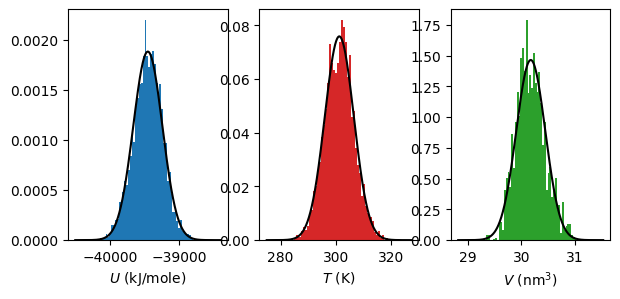

In [45]:
# Gráfico de histogramas com as distribuições de U, T e V
fig, axs = plt.subplots(1, 3,figsize=(7,3))

axs[0].hist(subsetU,bins=50,density=True)
axs[0].set_xlabel(r'$U$ (kJ/mole)')

uarray = Umean+np.arange(-5*sigmaU,5*sigmaU,0.01*sigmaU)
axs[0].plot(uarray,np.sqrt(1/(2*np.pi*sigmaU**2))*np.exp(-0.5*(uarray-Umean)**2/sigmaU**2),color='k')

axs[1].hist(subsetT,bins=50,density=True,color='C3')
axs[1].set_xlabel(r'$T$ (K)')

Tarray = Tmean + np.arange(-5*sigmaT,5*sigmaT,0.01*sigmaT)
axs[1].plot(Tarray,np.sqrt(1/(2*np.pi*sigmaT**2))*np.exp(-0.5*(Tarray-Tmean)**2/sigmaT**2),color='k')

axs[2].hist(subsetV,bins=50,density=True,color='C2')
axs[2].set_xlabel(r'$V$ (nm$^3$)')

Varray = Vmean + np.arange(-5*sigmaV,5*sigmaV,0.01*sigmaV)
axs[2].plot(Varray,np.sqrt(1/(2*np.pi*sigmaV**2))*np.exp(-0.5*(Varray-Vmean)**2/sigmaV**2),color='k')

> **<span style="color:#A03;font-size:14pt">
&#x270B; HANDS-ON! &#x1F528;
</span>**
>
> - Calcule a densidade da água para essa $T=300$ K e $P = 1$ bar e compare com o valor tabelado pelo NIST em $55315$ mol/m^3.
> - Estime a incerteza no valor da densidade calculada.

In [50]:
# Passo 1: define topologia da molécula
mol_topology = app.Topology()
chain = mol_topology.addChain()
residue = mol_topology.addResidue("water", chain)
element_O = app.Element.getByAtomicNumber(8)
element_H = app.Element.getByAtomicNumber(1)
atom0 = mol_topology.addAtom("O", element_O, residue)
atom1 = mol_topology.addAtom("H", element_H, residue)
atom2 = mol_topology.addAtom("H", element_H, residue)
mol_topology.addBond(atom0, atom1)
mol_topology.addBond(atom0, atom2)
bond = 0.95  # Å
angle = 105.0 * np.pi/180
eq_pos = np.array([
    [0.0,         0.0,         0.0        ],  # O
    [ bond,       0.0,         0.0        ],  # H1
    [ bond*np.cos(angle), bond*np.sin(angle), 0.0 ],  # H2
]) * angstrom
# Passo 2: constroi a caixa de simulação
L = 30 * angstrom
box_matrix = L * np.identity(3)
topology = Topology()
topology.setPeriodicBoxVectors(box_matrix)
N_mol = 1000
resname = next(mol_topology.residues()).name
for i in range(N_mol):
    chain   = topology.addChain()
    residue = topology.addResidue(resname, chain)
    atom_map = {}
    # 1) add atoms
    for atom in mol_topology.atoms():
        new = topology.addAtom(atom.name, atom.element, residue)
        atom_map[atom] = new
    # 2) add the same bonds
    for bond in mol_topology.bonds():
        a1 = atom_map[bond.atom1]
        a2 = atom_map[bond.atom2]
        topology.addBond(a1, a2)
# Passo 3: Coloca cada molécula em uma posição dentro da caixa cúbica
all_pos = []
i = 0
for x in np.arange(0,1.0,0.1)*L/angstrom:
  for y in np.arange(0,1.0,0.1)*L/angstrom:
    for z in np.arange(0,1.0,0.1)*L/angstrom:
      if i < N_mol:
        # CMpos = np.random.uniform(0, L / nanometer, 3)
        CMpos = np.array([x,y,z])
        coords = CMpos + eq_pos/nanometer
        all_pos.append(coords)
        i += 1
# Passo 4: Definindo ambiente de simulação
temperatura = 300 * kelvin
system = forcefield.createSystem(topology, nonbondedMethod=PME,
        nonbondedCutoff=1*nanometer, constraints=HBonds)
integrator = LangevinMiddleIntegrator(temperatura, 1/picosecond, 4*femtoseconds)
simulation = Simulation(topology, system, integrator,platform)
simulation.context.setPositions(np.vstack(all_pos) * angstrom)
simulation.minimizeEnergy()
simulation.context.setVelocitiesToTemperature(temperatura)
simulation.reporters = []
simulation.reporters.append(PDBReporter("output_water.pdb", 1000))
simulation.reporters.append(
    StateDataReporter(
        "md_log_water.csv",
        20,
        step=True,
        time=True,
        potentialEnergy=True,
        totalEnergy=True,
        temperature=True,
        volume=True
    )
)
simulation.reporters.append(
    StateDataReporter(stdout, 1000, step=True, totalEnergy=True,temperature=True,
        volume=True)
)
# Passo 5: Equilibração NVT
simulation.step(5000)
# Passo 6: Produção NPT
pressao = 1*bar
system.addForce(MonteCarloBarostat(pressao, temperatura))
simulation.context.reinitialize(preserveState=True)
simulation.step(70000)
# Passo 7: Lendo arquivo de dados
df = pd.read_csv("md_log_water.csv")
# Passo 8: Cálculando a média do volume
timecut = 50.0
subsetV = df['Box Volume (nm^3)'][df['Time (ps)'] > timecut]
Vmean = subsetV.mean()
# Passo 9: Cálcula a densidade numérica
nmean = N_mol/Vmean
print(f'Densidade média: {nmean:.2f} moleculas/nm3')

#"Step","Total Energy (kJ/mole)","Temperature (K)","Box Volume (nm^3)"
1000,-31301.108924300934,306.539158580518,27.0
2000,-31620.239905746246,295.4351473152781,27.0
3000,-31071.33359471109,307.612740721066,27.0
4000,-31864.72061863687,294.97671451369,27.0
5000,-31987.237372787262,296.8538885648065,27.0
6000,-31658.645735990955,295.4069128234337,28.726643307600185
7000,-31055.799024625652,291.55372721348374,29.39632838910914
8000,-31253.272358298855,300.20858935322735,30.055318591366518
9000,-30806.519077546458,305.93062302858937,29.87098711985628
10000,-30999.412640701135,291.9890621192466,29.825584201645082
11000,-30237.03999886624,307.87796365277944,30.453525691931116
12000,-30977.842612871173,297.141470796839,30.02042242553551
13000,-30819.45007280688,294.6135941049037,29.89555812656883
14000,-30810.271833987237,301.25749568936914,29.757509315405105
15000,-30614.30754818549,300.0902126371234,30.36786385672639
16000,-30802.711437237012,308.26122757536666,30.317214090968545
17000,-30

> **<span style="color:#A03;font-size:14pt">
&#x270B; HANDS-ON! &#x1F528;
</span>**
>
> Repita o cálculo agora com 1000 partículas de água na caixa mas durante 600 ps. A incerteza aumentou ou diminuiu?

😊 **BONUS:** Análise da incerteza com respeito ao número de moléculas na caixa

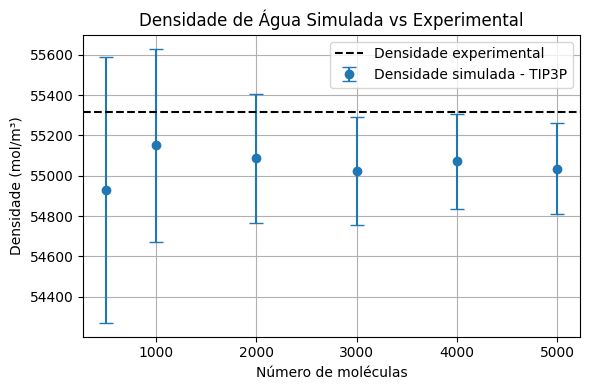

In [51]:
number_of_molecules = np.array([500, 1000, 2000, 3000, 4000, 5000])
density = np.array([54929.37,55151.03,55086.23,55022.79,55071.59,55035.42])
density_error = np.array([659.29, 479.79,320.27,266.33,235.66,226.33])

plt.figure(figsize=(6, 4))
plt.errorbar(number_of_molecules, density, yerr=density_error, fmt='o', capsize=5, color='C0', label='Densidade simulada - TIP3P')
plt.axhline(y=55315, color='k', linestyle='--', label='Densidade experimental')
plt.xlabel('Número de moléculas')
plt.ylabel('Densidade (mol/m³)')
plt.title('Densidade de Água Simulada vs Experimental')
plt.legend()
plt.grid()
plt.tight_layout()